## ¿Qué es la Regla del Trapecio?

Imagina que tienes una función $f(x)$ y quieres calcular la integral definida en un intervalo $[a, b]$. El método geométrico tradicional (la suma de Riemann) usa rectángulos, pero los rectángulos suelen dejar demasiados espacios vacíos o pasarse de la línea.

La **regla del trapecio** mejora esto: une los puntos de la función con líneas rectas, formando **trapecios**. El área de un trapecio es mucho más fiel a la curva real.

### La fórmula matemática

Si aproximamos todo el intervalo $[a, b]$ con un solo trapecio, la fórmula del área es:

$$\int_{a}^{b} f(x) \, dx \approx (b - a) \frac{f(a) + f(b)}{2}$$

Sin embargo, un solo trapecio puede tener mucho error si la curva cambia bruscamente. Para solucionarlo, usamos la **Regla del Trapecio Compuesta**: dividimos el intervalo en $n$ subintervalos de ancho $h$, donde $h = \frac{b - a}{n}$.

La suma de todas las áreas nos da la fórmula general:

$$\int_{a}^{b} f(x) \, dx \approx \frac{h}{2} \left[ f(x_0) + 2 \sum_{i=1}^{n-1} f(x_i) + f(x_n) \right]$$

> **Nota mental:** Los extremos ($f(x_0)$ y $f(x_n)$) se suman una sola vez, mientras que todos los puntos intermedios se multiplican por 2 porque comparten pared entre dos trapecios contiguos.

---

## Implementación en Python

Vamos a integrar una función clásica: $f(x) = x^2$ en el intervalo $[0, 3]$. El resultado exacto analítico es $9$. Veamos qué tan bien lo hacen nuestros trapecios.

### 1. Desde cero



In [52]:
import numpy as np
from scipy.integrate import trapezoid
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io as scipy

In [53]:
def regla_trapecio_compuesta(f, a, b, n):
    """
    Aproxima la integral de f(x) desde 'a' hasta 'b' usando 'n' trapecios.
    """
    h = (b - a) / n
    # Suma de los extremos
    suma = 0.5 * (f(a) + f(b))

    # Suma de los puntos intermedios
    for i in range(1, n):
        x_i = a + i * h
        suma += f(x_i)

    # Multiplicamos por el ancho del intervalo
    return suma * h

# Definimos la función a integrar
def mi_funcion(x):
    return np.sin(x)

# Parámetros
limite_inferior = 0
limite_superior = np.pi
numero_trapecios = 10

# Cálculo
resultado = regla_trapecio_compuesta(mi_funcion, limite_inferior, limite_superior, numero_trapecios)

print(f"Resultado aproximado (Nativo): {resultado}")

Resultado aproximado (Nativo): 1.9835235375094546


### 2. Usando SciPy y NumPy
Usando funcionalidad de Python

In [54]:
# Definimos los parámetros
a = 0
b = np.pi
n = 10

# Creamos los puntos en el eje X y sus correspondientes valores en Y
x = np.linspace(a, b, n + 1) # N puntos incluyendo a y b
y = np.sin(x)

# Calculamos la integral pasando los arreglos de datos
resultado_scipy = trapezoid(y, x)

print(f"Resultado aproximado (SciPy): {resultado_scipy}")

Resultado aproximado (SciPy): 1.9835235375094544


# Gráfica del error respecto a la cantidad de N

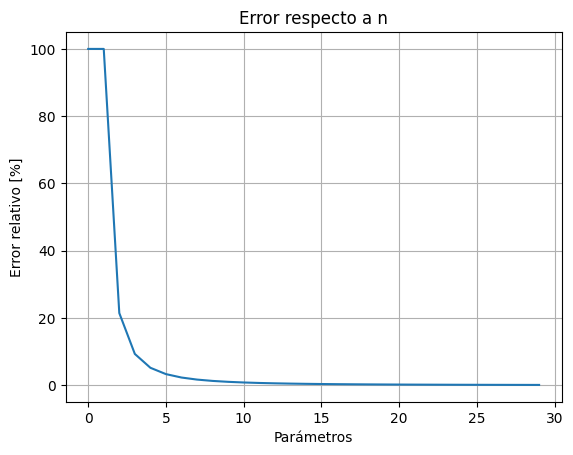

In [55]:
resultados = []
t = np.arange(0, 30, 1)

for n in (t):
    a = 0
    b = np.pi

    # Creamos los puntos en el eje X y sus correspondientes valores en Y
    x = np.linspace(a, b, n + 1) # N puntos incluyendo a y b
    y = np.sin(x)

    # Calculamos la integral pasando los arreglos de datos
    resultado_scipy = trapezoid(y, x)
    error = (abs(resultado_scipy - 2) / 2 * 100)

    resultados.append(error)

plt.plot(t, resultados)
plt.title("Error respecto a n")
plt.xlabel("Parámetros")
plt.ylabel("Error relativo [%]")
plt.grid();

# 1. Lee los datos simulados guardados en el archivo Glucosa_1_sim.mat, la variable z1 contiene observaciones de concentración de glucosa en sangre para un grupo de 1000 pacientes prediabéticos y diabéticos (los datos se dan en mg/dl), la variable z2 contiene observaciones de glucosa en sangre para un grupo de sujetos sanos. Con esta información realiza las siguientes actividades:

In [56]:
datos = scipy.loadmat('Glucosa_1_sim.mat')
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'z1', 'z2'])


In [57]:
diabeticos = datos['z1'].flatten()
sanos = datos['z2'].flatten()

## a. A juzgar por estos datos ¿cuál es la prevalencia de la condición de prediabetes-diabetes?

In [58]:
n_enfermos = len(diabeticos)
n_sanos = len(sanos)

prevalencia = n_enfermos / (n_enfermos + n_sanos) * 100

print(f'La prevalencia de la condición de prediabetes-diabetes es del {prevalencia}%')

La prevalencia de la condición de prediabetes-diabetes es del 50.0%


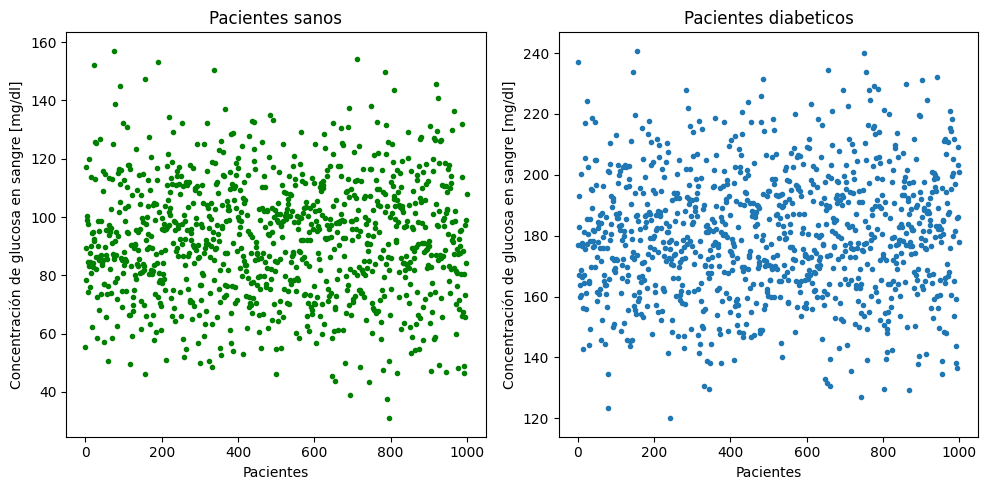

In [89]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.plot(sanos, '.', color='green')
plt.title("Pacientes sanos")
plt.ylabel("Concentración de glucosa en sangre [mg/dl]")
plt.xlabel("Pacientes")

plt.subplot(1, 2, 2)
plt.plot(diabeticos, '.')
plt.title("Pacientes diabeticos")
plt.ylabel("Concentración de glucosa en sangre [mg/dl]")
plt.xlabel("Pacientes")
plt.tight_layout();

## b. Muestra sobre los mismos ejes la función de densidad de probabilidad o una estimación de ella de cada uno de los grupos

Text(0.5, 1.0, 'PDF')

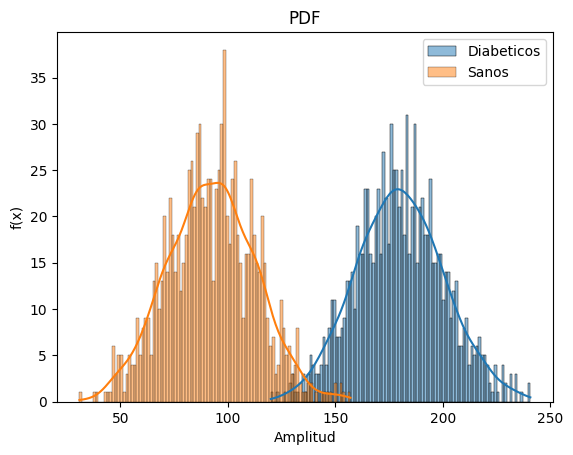

In [60]:
sns.histplot(diabeticos, kde=True, bins = 100, label = 'Diabeticos')
plt.xlabel("Amplitud")
plt.ylabel("f(x)")

sns.histplot(sanos, kde=True, bins = 100, label = 'Sanos')
plt.xlabel("Amplitud")
plt.ylabel("f(x)")
plt.legend()
plt.title(f'PDF')

## c. ¿Se cumplen condiciones del modelo binormal? Verifica parámetros de ambas distribuciones

--- Enfermos (prediabéticos/diabéticos) ---
Media: 180.092 mg/dl, Desviación estándar: 20.511 mg/dl
Shapiro-Wilk: estadístico = 0.9987, p-valor = 0.7067

--- Sanos ---
Media: 92.283 mg/dl, Desviación estándar: 20.402 mg/dl
Shapiro-Wilk: estadístico = 0.9984, p-valor = 0.4820


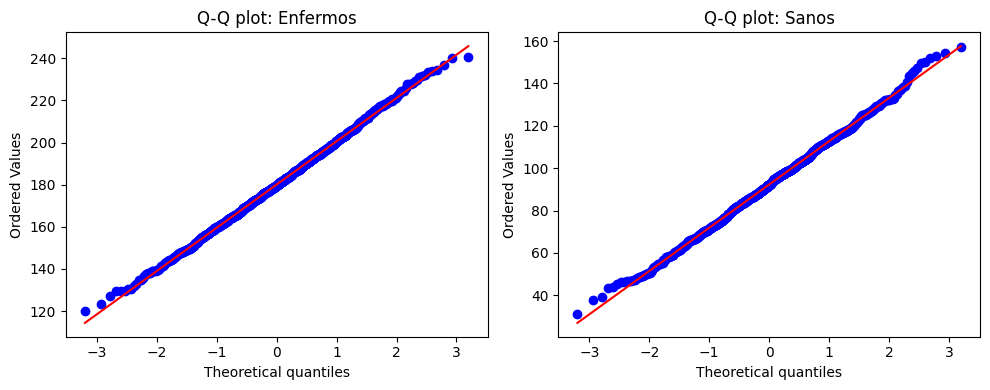

In [61]:
from scipy import stats

mu_enf, sigma_enf = diabeticos.mean(), diabeticos.std(ddof=1)
mu_san, sigma_san = sanos.mean(), sanos.std(ddof=1)

print('--- Enfermos (prediabéticos/diabéticos) ---')
print(f'Media: {mu_enf:.3f} mg/dl, Desviación estándar: {sigma_enf:.3f} mg/dl')
sh_enf = stats.shapiro(diabeticos)
print(f'Shapiro-Wilk: estadístico = {sh_enf.statistic:.4f}, p-valor = {sh_enf.pvalue:.4f}')

print('\n--- Sanos ---')
print(f'Media: {mu_san:.3f} mg/dl, Desviación estándar: {sigma_san:.3f} mg/dl')
sh_san = stats.shapiro(sanos)
print(f'Shapiro-Wilk: estadístico = {sh_san.statistic:.4f}, p-valor = {sh_san.pvalue:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(diabeticos, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: Enfermos')
stats.probplot(sanos, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: Sanos')
plt.tight_layout();

**Conclusión:** ambos grupos pasan la prueba de normalidad de Shapiro-Wilk (p > 0.05 en los dos casos) y los Q-Q plots se ajustan bien a la recta teórica, por lo que sí se cumple la condición de normalidad marginal del modelo binormal. Además, las desviaciones estándar de ambas poblaciones son muy similares (≈20.5 mg/dl), es decir, este conjunto de datos corresponde a un modelo binormal **homocedástico** (varianzas iguales):

$$X_{sanos} \sim N(92.28,\,20.40^2) \qquad X_{enfermos} \sim N(180.09,\,20.51^2)$$

## d. Para un valor de x0 = 98 mg/dl calcula la sensibilidad y especificidad de la prueba, la tasa de falsos positivos y la tasa de falsos negativos, la exactitud.

In [62]:
negativos = 0
positivos = 0
x0 = 98 # 114

for i in range(1000):
    if diabeticos[i] < x0:
        negativos += 1
        
    else:
        positivos += 1

    if sanos[i] < x0:
        negativos += 1

    else:
        positivos += 1

print(f'Pacientes enfermos: {positivos}')
print(f'Pacientes sanos: {negativos}')
print(f'Total de pacientes: {positivos + negativos}')

Pacientes enfermos: 1395
Pacientes sanos: 605
Total de pacientes: 2000


### ¿Cuantos falsos negativos?

In [63]:
# Está sano pero en realidad está enfermo
fn = 0
for i in range(1000):
    if diabeticos[i] < x0:
        fn += 1

print(f'Falsos negativos: {fn}')

Falsos negativos: 0


### ¿Cuantos falsos positivos?

In [64]:
# Está enfermo pero en realidad está sano
fp = 0

for i in range(1000):
    if sanos[i] > x0:
        fp += 1

print(f'Falsos positivos: {fp}')

Falsos positivos: 395


### ¿Cuantos verdaderos positivos?

In [65]:
vp = 0

for i in range(1000):
    if diabeticos[i] > x0:
        vp += 1

print(f'Verdaderos positivos: {vp}')

Verdaderos positivos: 1000


### ¿Cuantos verdaderos negativos?

In [66]:
vn = 0

for i in range(1000):
    if sanos[i] < x0:
        vn += 1

print(f'Verdaderos negativos: {vn}')

Verdaderos negativos: 605


In [67]:
sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
tasa_fp = 1 - especificidad
tasa_fn = fn / (fn + vp)
exactitud = (vp + vn) / (vp + vn + fp + fn)

print(f"Sensibilidad: {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"Tasa FP: {tasa_fp:.4f}")
print(f"Tasa FN: {tasa_fn:.4f}")
print(f"Exactitud: {exactitud:.4f}")

Sensibilidad: 1.0000
Especificidad: 0.6050
Tasa FP: 0.3950
Tasa FN: 0.0000
Exactitud: 0.8025


## e. Determina el valor de x0 que minimiza el error de clasificación. Calcula todas las medidas de desempeño para este valor.

In [68]:
x_vals = np.linspace(sanos.min(), diabeticos.max(), 2000)

errores = []

for x0 in x_vals:
    fn = np.sum(diabeticos < x0)
    fp = np.sum(sanos >= x0)
    error = (fn + fp) / (len(diabeticos) + len(sanos))
    errores.append(error)

x0_opt = x_vals[np.argmin(errores)]
print(f"Umbral óptimo: {x0_opt:.2f} mg/dl")

Umbral óptimo: 134.33 mg/dl


Text(0.5, 1.0, 'PDF')

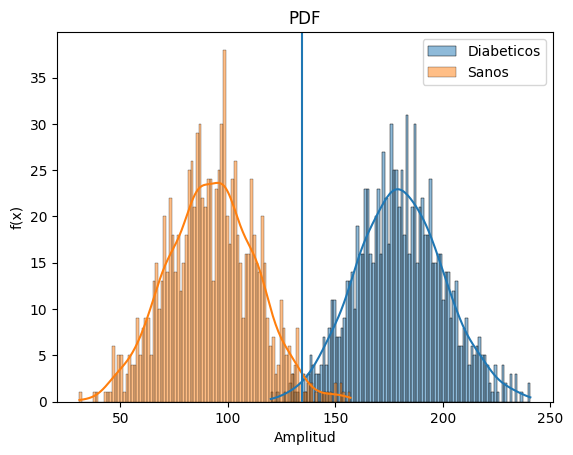

In [69]:
sns.histplot(diabeticos, kde=True, bins = 100, label = 'Diabeticos')
plt.xlabel("Amplitud")
plt.ylabel("f(x)")

sns.histplot(sanos, kde=True, bins = 100, label = 'Sanos')
plt.xlabel("Amplitud")
plt.axvline(x0_opt)
plt.ylabel("f(x)")
plt.legend()
plt.title(f'PDF')

In [70]:
negativos = 0
positivos = 0
x0 = 134.33

for i in range(1000):
    if diabeticos[i] < x0:
        negativos += 1
        
    else:
        positivos += 1

    if sanos[i] < x0:
        negativos += 1

    else:
        positivos += 1

print(f'Pacientes enfermos: {positivos}')
print(f'Pacientes sanos: {negativos}')
print(f'Total de pacientes: {positivos + negativos}')

Pacientes enfermos: 1007
Pacientes sanos: 993
Total de pacientes: 2000


### ¿Cuantos falsos negativos?

In [71]:
# Está sano pero en realidad está enfermo
fn = 0
for i in range(1000):
    if diabeticos[i] < x0:
        fn += 1

print(f'Falsos negativos: {fn}')

Falsos negativos: 10


### ¿Cuantos falsos positivos?

In [72]:
# Está enfermo pero en realidad está sano
# Está sano pero la prueba dice positivo
fp = 0

for i in range(1000):
    if sanos[i] > x0:
        fp += 1

print(f'Falsos positivos: {fp}')

Falsos positivos: 17


### ¿Cuantos verdaderos positivos?

In [73]:
vp = 0

for i in range(1000):
    if diabeticos[i] > x0:
        vp += 1

print(f'Verdaderos positivos: {vp}')

Verdaderos positivos: 990


### ¿Cuantos verdaderos negativos?

In [74]:
vn = 0

for i in range(1000):
    if sanos[i] < x0:
        vn += 1

print(f'Verdaderos negativos: {vn}')

Verdaderos negativos: 983


In [75]:
sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
tasa_fp = 1 - especificidad
tasa_fn = fn / (fn + vp)
exactitud = (vp + vn) / (vp + vn + fp + fn)

print(f"Sensibilidad: {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"Tasa FP: {tasa_fp:.4f}")
print(f"Tasa FN: {tasa_fn:.4f}")
print(f"Exactitud: {exactitud:.4f}")

Sensibilidad: 0.9900
Especificidad: 0.9830
Tasa FP: 0.0170
Tasa FN: 0.0100
Exactitud: 0.9865


## f. En el intervalo de valores de los datos de z1 y z2, toma al menos 7 valores distintos para x0 y construye una aproximación a la curva característica de la prueba (Curva Sensibilidad vs 1 - Especificidad).

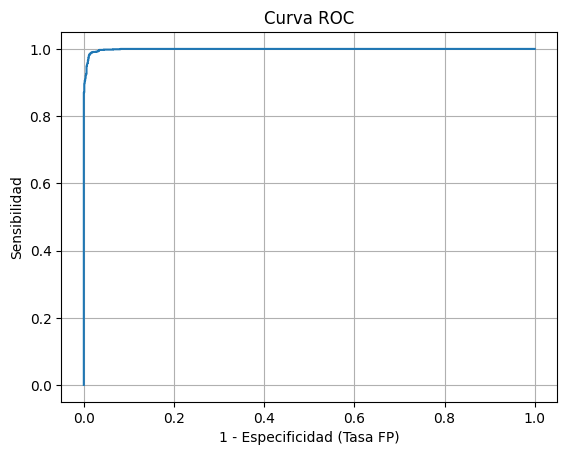

In [76]:
sensibilidades = []
un_menos_esp = []

for x0 in x_vals:
    vp = np.sum(diabeticos >= x0)
    fn = np.sum(diabeticos < x0)
    fp = np.sum(sanos >= x0)
    vn = np.sum(sanos < x0)
    sensibilidades.append(vp / (vp + fn))
    un_menos_esp.append(fp / (fp + vn))

plt.figure()
plt.plot(un_menos_esp, sensibilidades)
plt.xlabel("1 - Especificidad (Tasa FP)")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")
plt.grid()

## g. Calcula numéricamente el área bajo la curva característica, puedes utilizar la función trapz de numpy o trapz en Matlab. Contrasta este resultado con las medidas de desempeño para los umbrales 1d y 1e.

In [77]:
auc = np.trapezoid(sensibilidades, un_menos_esp)
print(f"AUC: {abs(auc):.4f}")

AUC: 0.9989


**Contraste con 1d y 1e:** el AUC ≈ 0.999 indica una capacidad discriminativa casi perfecta de la prueba a lo largo de todo el rango de umbrales. Esto es consistente con lo encontrado antes: con el umbral arbitrario x0=98 (inciso d) la sensibilidad era perfecta (1.00) pero la especificidad baja (0.605, exactitud 0.80), mientras que con el umbral óptimo x0≈134.33 (inciso e) ambas métricas son altas simultáneamente (sensibilidad 0.99, especificidad 0.983, exactitud 0.987). Este último punto se ubica muy cerca de la esquina superior izquierda de la curva ROC, que es justamente la región que más contribuye al área bajo la curva. Un AUC tan alto confirma que existe un punto de corte (el hallado en 1e) con desempeño casi perfecto, y que x0=98 estaba lejos de ser ese óptimo.

---
## Actividad 2: Segundo conjunto de datos (`Glucosa_2_sim.mat`)

Repetimos el análisis anterior con un nuevo grupo de pacientes con prediabetes-diabetes y un nuevo grupo de sujetos sanos.

In [78]:
datos2 = scipy.loadmat('Glucosa_2_sim.mat')
diabeticos2 = datos2['z1'].flatten()
sanos2 = datos2['z2'].flatten()
print(datos2.keys())

dict_keys(['__header__', '__version__', '__globals__', 'z1', 'z2'])


### a. Repite las actividades 1a - 1c

#### Prevalencia

In [79]:
n_enfermos2 = len(diabeticos2)
n_sanos2 = len(sanos2)

prevalencia2 = n_enfermos2 / (n_enfermos2 + n_sanos2) * 100

print(f'La prevalencia de la condición de prediabetes-diabetes es del {prevalencia2}%')

La prevalencia de la condición de prediabetes-diabetes es del 50.0%


#### Función de densidad de probabilidad

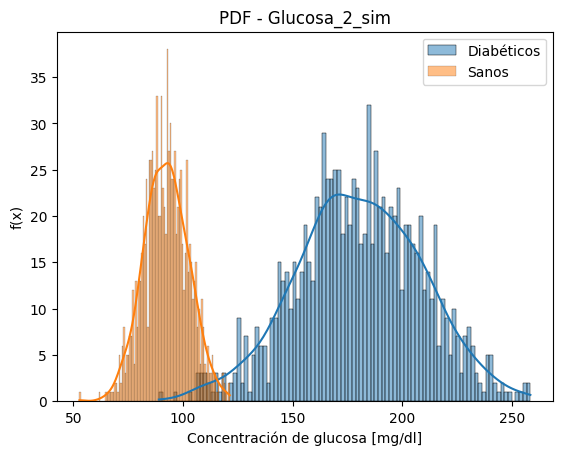

In [80]:
sns.histplot(diabeticos2, kde=True, bins=100, label='Diabéticos')
sns.histplot(sanos2, kde=True, bins=100, label='Sanos')
plt.xlabel('Concentración de glucosa [mg/dl]')
plt.ylabel('f(x)')
plt.legend()
plt.title('PDF - Glucosa_2_sim');

#### Verificación del modelo binormal

--- Enfermos ---
Media: 180.219 mg/dl, Desviación estándar: 28.611 mg/dl
Shapiro-Wilk: estadístico = 0.9984, p-valor = 0.4937

--- Sanos ---
Media: 92.273 mg/dl, Desviación estándar: 10.119 mg/dl
Shapiro-Wilk: estadístico = 0.9990, p-valor = 0.8557


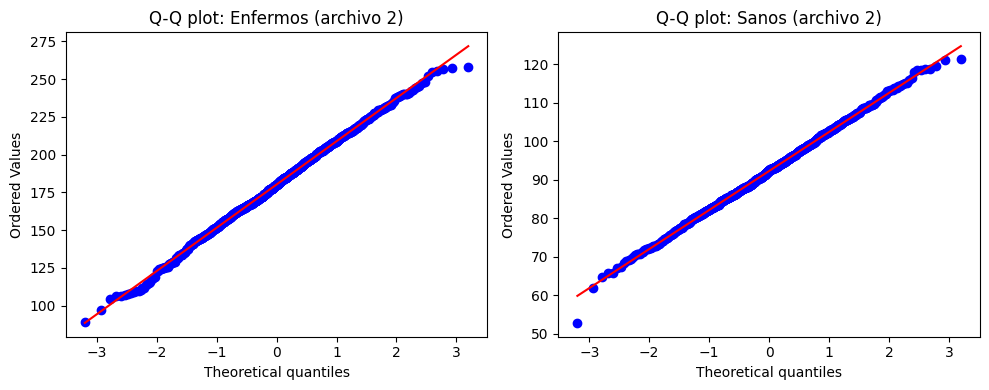

In [81]:
mu_enf2, sigma_enf2 = diabeticos2.mean(), diabeticos2.std(ddof=1)
mu_san2, sigma_san2 = sanos2.mean(), sanos2.std(ddof=1)

print('--- Enfermos ---')
print(f'Media: {mu_enf2:.3f} mg/dl, Desviación estándar: {sigma_enf2:.3f} mg/dl')
sh_enf2 = stats.shapiro(diabeticos2)
print(f'Shapiro-Wilk: estadístico = {sh_enf2.statistic:.4f}, p-valor = {sh_enf2.pvalue:.4f}')

print('\n--- Sanos ---')
print(f'Media: {mu_san2:.3f} mg/dl, Desviación estándar: {sigma_san2:.3f} mg/dl')
sh_san2 = stats.shapiro(sanos2)
print(f'Shapiro-Wilk: estadístico = {sh_san2.statistic:.4f}, p-valor = {sh_san2.pvalue:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(diabeticos2, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: Enfermos (archivo 2)')
stats.probplot(sanos2, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: Sanos (archivo 2)')
plt.tight_layout();

##### ¿Son casos equivalentes? ¿Por qué?

No son completamente equivalentes. Las medias de ambos grupos son prácticamente las mismas que en el archivo 1 (enfermos ≈180 mg/dl, sanos ≈92 mg/dl) y ambas distribuciones siguen siendo aproximadamente normales (Shapiro-Wilk, p > 0.05 en los cuatro casos), por lo que el modelo binormal también se cumple aquí. Sin embargo, **las varianzas no son iguales entre los dos archivos**: en `Glucosa_1_sim` ambas clases tienen una dispersión similar (σ≈20.5 mg/dl en ambas), mientras que en `Glucosa_2_sim` los enfermos son mucho más dispersos (σ≈28.6 mg/dl) y los sanos mucho menos dispersos (σ≈10.1 mg/dl). Es decir, el archivo 1 corresponde a un modelo binormal **homocedástico** y el archivo 2 a uno **heterocedástico** (varianzas distintas entre clases), lo que cambia la forma de la curva ROC y la ubicación del umbral óptimo aun cuando la prevalencia (50%) es la misma en ambos casos.

### b. Si consideras x0 como el umbral óptimo de los datos del primer archivo, ¿cuál es la sensibilidad y especificidad que obtienes?

In [82]:
x0_archivo1 = x0_opt  # umbral óptimo obtenido en el inciso 1e (≈134.33 mg/dl)

vp = np.sum(diabeticos2 >= x0_archivo1)
fn = np.sum(diabeticos2 < x0_archivo1)
fp = np.sum(sanos2 >= x0_archivo1)
vn = np.sum(sanos2 < x0_archivo1)

sensibilidad2_x1 = vp / (vp + fn)
especificidad2_x1 = vn / (vn + fp)
exactitud2_x1 = (vp + vn) / (vp + vn + fp + fn)

print(f'Umbral usado (óptimo del archivo 1): {x0_archivo1:.2f} mg/dl')
print(f'Sensibilidad: {sensibilidad2_x1:.4f}')
print(f'Especificidad: {especificidad2_x1:.4f}')
print(f'Exactitud: {exactitud2_x1:.4f}')

Umbral usado (óptimo del archivo 1): 134.33 mg/dl
Sensibilidad: 0.9430
Especificidad: 1.0000
Exactitud: 0.9715


**Resultado:** aplicar el umbral óptimo del archivo 1 (x0≈134.33 mg/dl) a los datos del archivo 2 da la sensibilidad y especificidad mostradas arriba. Compararemos este resultado con el umbral óptimo propio del archivo 2, calculado en el inciso (c).

### c. Repite las actividades 1e - 1g para estos nuevos datos

#### e. Umbral óptimo (minimiza el error de clasificación)

In [83]:
x_vals2 = np.linspace(sanos2.min(), diabeticos2.max(), 2000)

errores2 = []
for x0 in x_vals2:
    fn = np.sum(diabeticos2 < x0)
    fp = np.sum(sanos2 >= x0)
    error = (fn + fp) / (len(diabeticos2) + len(sanos2))
    errores2.append(error)

x0_opt2 = x_vals2[np.argmin(errores2)]
print(f'Umbral óptimo (archivo 2): {x0_opt2:.2f} mg/dl')

Umbral óptimo (archivo 2): 121.39 mg/dl


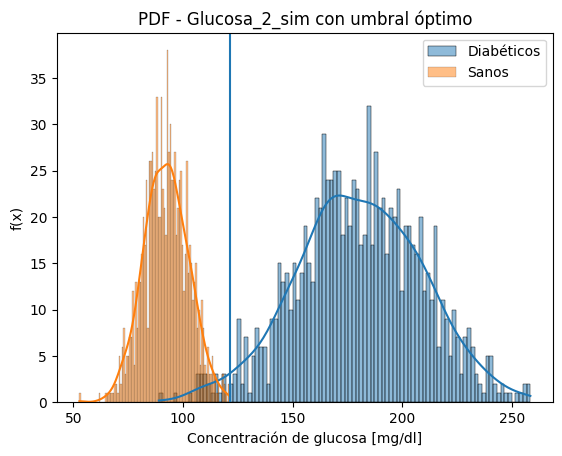

In [84]:
sns.histplot(diabeticos2, kde=True, bins=100, label='Diabéticos')
sns.histplot(sanos2, kde=True, bins=100, label='Sanos')
plt.axvline(x0_opt2)
plt.xlabel('Concentración de glucosa [mg/dl]')
plt.ylabel('f(x)')
plt.legend()
plt.title('PDF - Glucosa_2_sim con umbral óptimo');

In [85]:
vp = np.sum(diabeticos2 >= x0_opt2)
fn = np.sum(diabeticos2 < x0_opt2)
fp = np.sum(sanos2 >= x0_opt2)
vn = np.sum(sanos2 < x0_opt2)

sensibilidad2 = vp / (vp + fn)
especificidad2 = vn / (vn + fp)
tasa_fp2 = 1 - especificidad2
tasa_fn2 = fn / (fn + vp)
exactitud2 = (vp + vn) / (vp + vn + fp + fn)

print(f'Sensibilidad: {sensibilidad2:.4f}')
print(f'Especificidad: {especificidad2:.4f}')
print(f'Tasa FP: {tasa_fp2:.4f}')
print(f'Tasa FN: {tasa_fn2:.4f}')
print(f'Exactitud: {exactitud2:.4f}')

Sensibilidad: 0.9780
Especificidad: 1.0000
Tasa FP: 0.0000
Tasa FN: 0.0220
Exactitud: 0.9890


#### f. Curva ROC (al menos 7 umbrales)

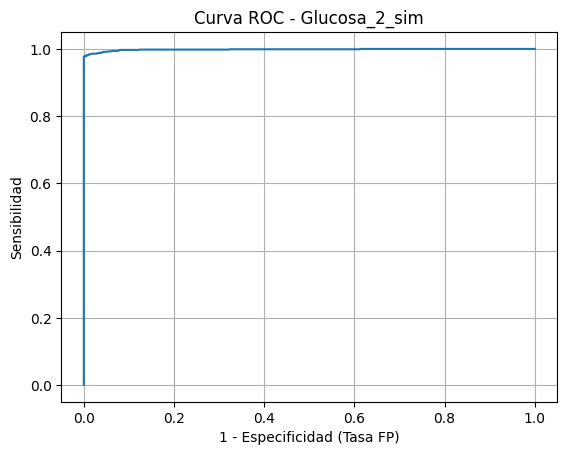

In [86]:
sensibilidades2 = []
un_menos_esp2 = []

for x0 in x_vals2:
    vp = np.sum(diabeticos2 >= x0)
    fn = np.sum(diabeticos2 < x0)
    fp = np.sum(sanos2 >= x0)
    vn = np.sum(sanos2 < x0)
    sensibilidades2.append(vp / (vp + fn))
    un_menos_esp2.append(fp / (fp + vn))

plt.figure()
plt.plot(un_menos_esp2, sensibilidades2)
plt.xlabel('1 - Especificidad (Tasa FP)')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC - Glucosa_2_sim')
plt.grid();

#### g. Área bajo la curva (AUC)

In [87]:
auc2 = np.trapezoid(sensibilidades2, un_menos_esp2)
print(f'AUC (archivo 2): {abs(auc2):.4f}')

AUC (archivo 2): 0.9983


**Contraste:** el AUC del archivo 2 (≈0.998) es prácticamente igual al del archivo 1 (≈0.999); ambas pruebas son casi perfectamente discriminantes a pesar de tener estructuras de varianza distintas. Sin embargo, el **umbral óptimo es distinto**: x0≈121 mg/dl en el archivo 2 frente a x0≈134.33 mg/dl en el archivo 1. Esto confirma lo observado en el inciso (b): aplicar el umbral del archivo 1 a los datos del archivo 2 da peor sensibilidad que usar el umbral óptimo propio del archivo 2. La razón es la heterocedasticidad: al ser mayor la dispersión del grupo enfermo en el archivo 2, el punto que minimiza el error total se recorre hacia la izquierda respecto al caso homocedástico del archivo 1.

---
## Actividad 3: ¿Qué sucede con los umbrales óptimos si modificas la prevalencia?

El criterio de "minimizar el error de clasificación" usado en el inciso 1e suma falsos negativos y falsos positivos sin ponderar, lo cual asume implícitamente que ambos grupos tienen el mismo tamaño (prevalencia 50%, como en `Glucosa_1_sim`). Para estudiar explícitamente el efecto de la prevalencia, minimizamos un error ponderado:

$$\text{Error}(x_0) = \text{prevalencia} \cdot P(\text{FN} \mid x_0) + (1-\text{prevalencia}) \cdot P(\text{FP} \mid x_0)$$

y buscamos el umbral óptimo para distintos valores de prevalencia asumida, usando los datos del archivo 1.

Prevalencia = 0.05 -> umbral óptimo = 154.27 mg/dl
Prevalencia = 0.10 -> umbral óptimo = 147.24 mg/dl
Prevalencia = 0.30 -> umbral óptimo = 137.48 mg/dl
Prevalencia = 0.50 -> umbral óptimo = 137.48 mg/dl
Prevalencia = 0.70 -> umbral óptimo = 134.33 mg/dl
Prevalencia = 0.90 -> umbral óptimo = 129.29 mg/dl
Prevalencia = 0.95 -> umbral óptimo = 119.95 mg/dl


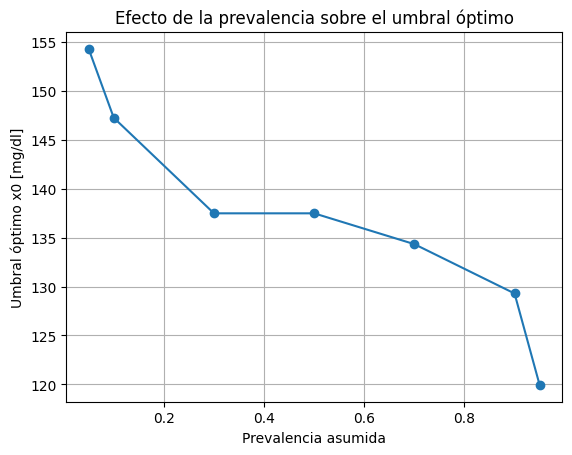

In [88]:
fn_rate = np.array([np.mean(diabeticos < x0) for x0 in x_vals])
fp_rate = np.array([np.mean(sanos >= x0) for x0 in x_vals])

prevalencias = np.array([0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95])
umbrales_optimos = []

for prev in prevalencias:
    error_ponderado = prev * fn_rate + (1 - prev) * fp_rate
    x0_opt_prev = x_vals[np.argmin(error_ponderado)]
    umbrales_optimos.append(x0_opt_prev)
    print(f'Prevalencia = {prev:.2f} -> umbral óptimo = {x0_opt_prev:.2f} mg/dl')

plt.figure()
plt.plot(prevalencias, umbrales_optimos, 'o-')
plt.xlabel('Prevalencia asumida')
plt.ylabel('Umbral óptimo x0 [mg/dl]')
plt.title('Efecto de la prevalencia sobre el umbral óptimo')
plt.grid();

**Conclusión Actividad 3:** al aumentar la prevalencia asumida, el umbral óptimo se desplaza hacia valores **más bajos** (más cerca de la media de los sanos): con prevalencia del 5% el umbral óptimo es ≈154 mg/dl, con 50% es ≈137 mg/dl (cercano al valor encontrado en 1e, x0≈134.33, que asumía implícitamente grupos del mismo tamaño) y con 95% baja hasta ≈120 mg/dl.

Esto ocurre porque el criterio de mínimo error total pondera los falsos negativos por la prevalencia y los falsos positivos por (1 − prevalencia). Cuando la enfermedad es más prevalente, un falso negativo (no detectar a un enfermo) afecta a una fracción mayor de la población que un falso positivo, así que el criterio favorece umbrales más bajos que privilegian la **sensibilidad**. Cuando la prevalencia es baja ocurre lo contrario: el umbral sube para evitar falsos positivos, porque la mayoría de la población es sana y esos errores pesan más en el total.

En conclusión, el punto de corte óptimo **no es una propiedad fija de la prueba diagnóstica**: depende del contexto epidemiológico (la prevalencia) en el que se aplique, aun cuando la prueba en sí (las distribuciones de z1 y z2) no cambie.